# **Thresholding, Binarization & Adaptive Thresholding**

## **Objectives:**
1. Binarized Images
2. Thresholding Methods
3. Adaptive Thresholding
4. SkImage's Threshold Local

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

### How Otsu's method picks its own threshold

Every fixed threshold above (`127`) is a guess. `cv2.THRESH_OTSU` doesn't guess — it looks at the image's brightness histogram and tries *every possible* threshold value from 0 to 255, scoring each one by how cleanly it splits the pixels into two groups. The score it's optimizing is the **between-class variance**: pick the split point where the two resulting groups ("dark pixels" and "light pixels") are each as internally consistent as possible, and as different from each other as possible. On an image like `page.jpg` — mostly white paper, mostly dark ink, not much in between — the histogram has two clear humps, and Otsu's threshold lands right in the valley between them, almost exactly where you'd point with a finger.

**Adaptive thresholding** solves a different problem: uneven lighting across a single image (a shadow across half the page) means *no single* threshold works everywhere. Instead of one global cutoff, it computes a local cutoff for every pixel from its own neighborhood's mean brightness — a moving, local version of the same "split into two groups" idea.

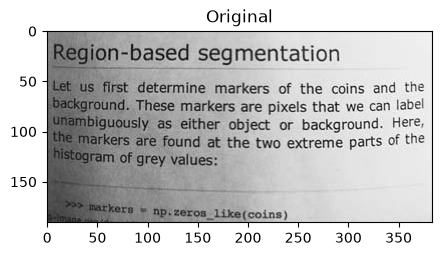

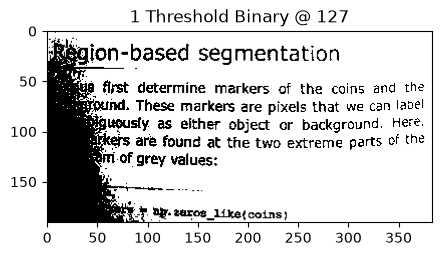

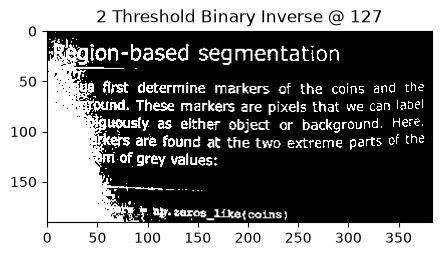

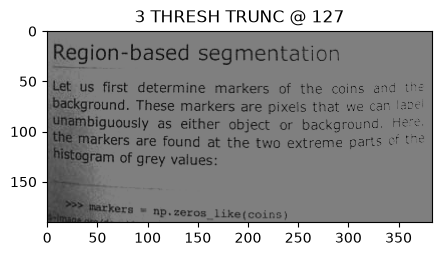

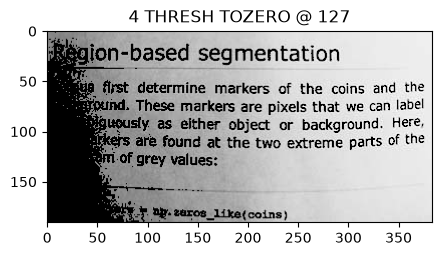

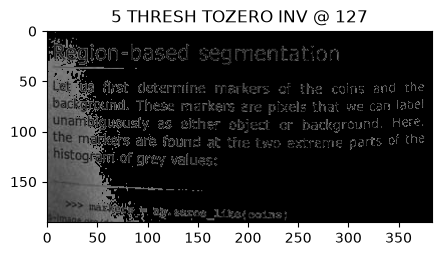

In [2]:
# Load our image as greyscale 
image = cv2.imread('./assets/images/page.jpg',0)
imshow("Original", image)

# Values below 127 goes to 0 or black, everything above goes to 255 (white)
ret,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
imshow('1 Threshold Binary @ 127', thresh1)

# Values below 127 go to 255 and values above 127 go to 0 (reverse of above)
ret,thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
imshow('2 Threshold Binary Inverse @ 127', thresh2)

# Values above 127 are truncated (held) at 127 (the 255 argument is unused)
ret,thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)
imshow('3 THRESH TRUNC @ 127', thresh3)

# Values below 127 go to 0, above 127 are unchanged  
ret,thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)
imshow('4 THRESH TOZERO @ 127', thresh4)

# Reverse of the above, below 127 is unchanged, above 127 goes to 0
ret,thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)
imshow('5 THRESH TOZERO INV @ 127', thresh5)

#### **Adaptive Thresholding**

1. ADAPTIVE_THRESH_MEAN_C
2. THRESH_OTSU

#### **cv2.adaptiveThreshold Parameters**

``cv2.adaptiveThreshold**(src, maxValue, adaptiveMethod, thresholdType, blockSize, C[, dst]) → dst``

- **src** – Source 8-bit single-channel image.
- **dst** – Destination image of the same size and the same type as src .
- **maxValue** – Non-zero value assigned to the pixels for which the condition is satisfied. See the details below.
- **adaptiveMethod** – Adaptive thresholding algorithm to use, ADAPTIVE_THRESH_MEAN_C or ADAPTIVE_THRESH_GAUSSIAN_C . See the details below.
- **thresholdType** – Thresholding type that must be either THRESH_BINARY or THRESH_BINARY_INV .
- **blockSize** – Size of a pixel neighborhood that is used to calculate a threshold value for the pixel: 3, 5, 7, and so on.
- **C** – Constant subtracted from the mean or weighted mean. Normally, it is positive but may be zero or negative as well.


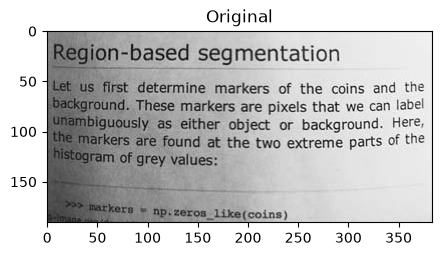

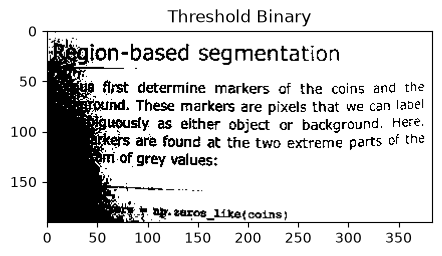

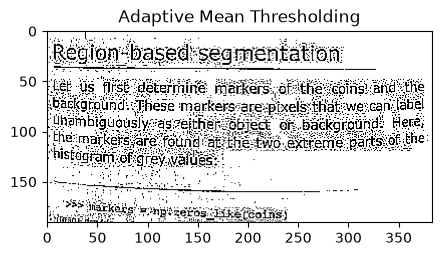

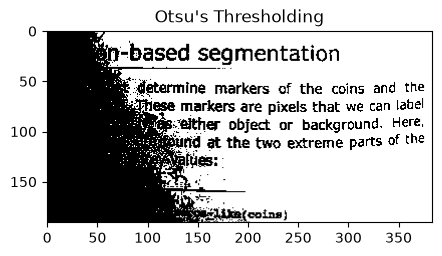

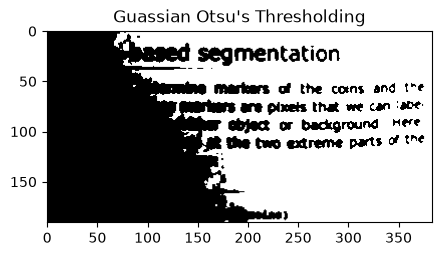

In [3]:
image = cv2.imread('./assets/images/page.jpg',0)
imshow("Original", image)

# Values below 127 goes to 0 (black, everything above goes to 255 (white)
ret,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
imshow('Threshold Binary', thresh1)

# It's good practice to blur images as it removes noise
#image = cv2.GaussianBlur(image, (3, 3), 0)

# Using adaptiveThreshold
thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 3, 5) 
imshow("Adaptive Mean Thresholding", thresh) 

_, th2 = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow("Otsu's Thresholding", th2) 

# Otsu's thresholding after Gaussian filtering
blur = cv2.GaussianBlur(image, (5,5), 0)
_, th3 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imshow("Guassian Otsu's Thresholding", th3) 

### **SkImage Threshold Local**


``threshold_local(image, block_size, offset=10)``

The threshold_local function, calculates thresholds in regions with a characteristic size ``block_size`` surrounding each pixel (i.e. local neighborhoods). Each threshold value is the weighted mean of the local neighborhood minus an ``offset`` value


https://scikit-image.org/docs/stable/auto_examples/applications/plot_thresholding.html

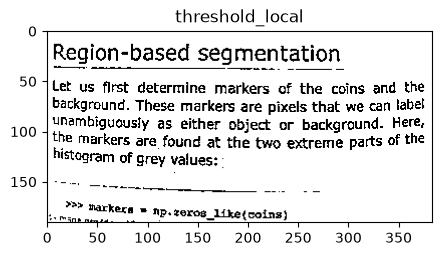

In [4]:
from skimage.filters import threshold_local

image = cv2.imread('./assets/images/page.jpg')

# We get the Value component from the HSV color space 
# then we apply adaptive thresholdingto 
V = cv2.split(cv2.cvtColor(image, cv2.COLOR_BGR2HSV))[2]
T = threshold_local(V, 25, offset=15, method="gaussian")

# Apply the threshold operation 
thresh = (V > T).astype("uint8") * 255
imshow("threshold_local", thresh)

### A couple of directions to take this

- `images/page.jpg` has uneven lighting across the page — that's exactly the case adaptive thresholding is for. Compare `THRESH_BINARY` (global) against `adaptiveThreshold` side by side with `nb_utils.show_grid`.
- Sweep the Otsu threshold's chosen value: print `ret` from `cv2.threshold(..., cv2.THRESH_OTSU)` and confirm it lands near the valley between the two peaks of `plt.hist(image.ravel(), 256)`.